# Problems in Linear Regression

This notebook addresses potential problems when running a linear regression model using AI tools to generate synthetic data & explore these problems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

np.random.seed(42)

# Issue 1: Non-linearity

A linear regression assumes a linear relationship between predictor and response. If the true relationship is not linear, any conclusions that result from using a linear regression are misleading and suspicious. One approach to address this is to investigate the residuals of our data, specifically plotting residuals on the y-axis and predicted values. When fitting a smoothed line to these data points, the line should be as flat as possible, indicating a good linear relationship. If the data looks non-linear, transformations could be applied to the predictors that could provide more linear-like residuals.

**Q:** What are the limitations to the non-linear transformations?

**A:** One limitation to doing this is coefficients no longer are interpretable as 'one unit increase in X..', which may affect communicating results. Another limitation is some relationships may just be too complex to do a simple transform if sticking with a linear model, perhaps a different model could fit the data better.

Text(0.5, 1.02, 'Linear Regression Diagnostic: Non-Linearity')

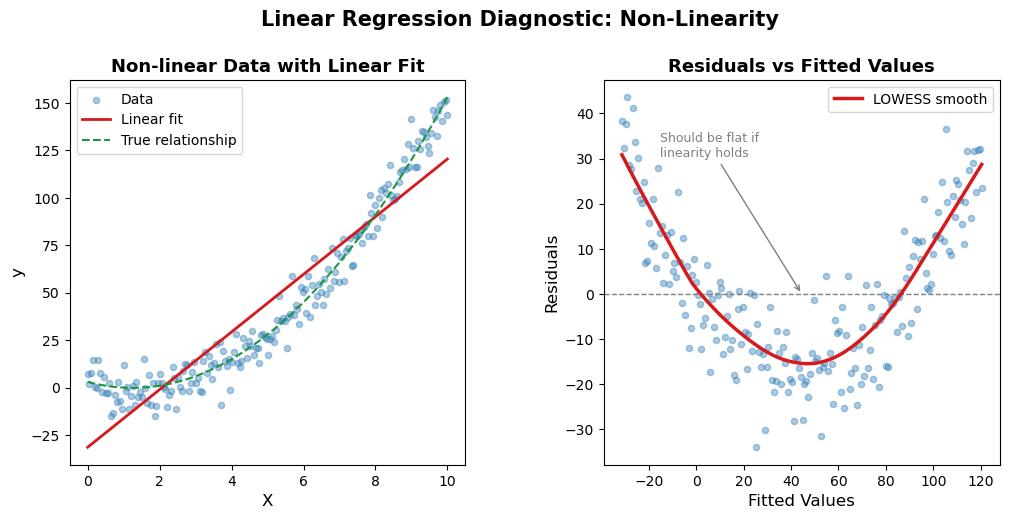

In [2]:
# --- Generate non-linear data ---
n = 200
X = np.linspace(0, 10, n)
y = 2 * X**2 - 5 * X + 3 + np.random.normal(0, 8, n)

# Fit linear regression (misspecified)
X_2d = X.reshape(-1, 1)
model = LinearRegression().fit(X_2d, y)
fitted = model.predict(X_2d)
residuals = y - fitted

# LOWESS smooth for residual plot
smoothed = lowess(residuals, fitted, frac=0.4)
# --- Plot ---
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# Left: Data + linear fit
ax1 = fig.add_subplot(gs[0])
ax1.scatter(X, y, alpha=0.4, s=20, color="#2c7bb6", label="Data")
ax1.plot(X, fitted, color="#d7191c", linewidth=2, label="Linear fit")

# True curve for reference
x_true = np.linspace(0, 10, 300)
ax1.plot(x_true, 2 * x_true**2 - 5 * x_true + 3, color="#1a9641",
         linewidth=1.5, linestyle="--", label="True relationship")

ax1.set_xlabel("X", fontsize=12)
ax1.set_ylabel("y", fontsize=12)
ax1.set_title("Non-linear Data with Linear Fit", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)

# Right: Residuals vs Fitted
ax2 = fig.add_subplot(gs[1])
ax2.axhline(0, color="gray", linewidth=1, linestyle="--")
ax2.scatter(fitted, residuals, alpha=0.4, s=20, color="#2c7bb6")
ax2.plot(smoothed[:, 0], smoothed[:, 1], color="#d7191c", linewidth=2.5,
         label="LOWESS smooth")

ax2.set_xlabel("Fitted Values", fontsize=12)
ax2.set_ylabel("Residuals", fontsize=12)
ax2.set_title("Residuals vs Fitted Values", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)

# Annotation
ax2.annotate("Should be flat if\nlinearity holds",
             xy=(fitted.mean(), 0), xytext=(fitted.mean() - 60, residuals.max() * 0.7),
             fontsize=9, color="gray",
             arrowprops=dict(arrowstyle="->", color="gray"))

fig.suptitle("Linear Regression Diagnostic: Non-Linearity", fontsize=15, fontweight="bold", y=1.02)

The generated data and plots took one iteration for Claude to generate as I tasked Claude with generating the data and described the issue the plots should show. The first step was to check the non-linear data that it generated and this was confirmed by looking at this line `y = 2 * X**2 - 5 * X + 3 + np.random.normal(0, 8, n)`. The result was a variable `y` that holds a quadratic relationship with respect to `X`. On the left is the raw data with a linear fit as well as the true relationship. On the right is the residuals and fitted values plot, showing that the data is indeed non-linear with the U-shape of residuals.

# Issue 2: Correlation of error terms

In addition to assuming linearity, the linear regression also assumes that error terms are uncorrelated. In other words for each error term, it should not affect any adjacent error term. This is frequently seen in time series data where a data point at one timestep is likely influenced/influences its adjacent data points at nearby timesteps, resulting in positively correlated errors. The consequence of having correlated errors is an unwarranted sense of confidence in the regression model due to the non-independence of the data.

**Q:** How do we handle autocorrelation? Is it something that we just mention and don't 'fix' or are there methods to handle the effects of positive error correlation.

**A:** There seem to be a handful of tests and tools to dealing with this. First, diagnosing with ACF plots or a Durbin-Watson test. Then, fix the model, autocorrelation could be addressed in a couple ways but one way is creating a lagged predictor, this absorbs the correlation and could help with a fix. Still, a missing predictor that's not capturing the whole relationship is something to consider to implement as well.

Text(0.5, 1.02, 'Linear Regression Diagnostic: Correlated Errors (AR(1), ρ=0.85)')

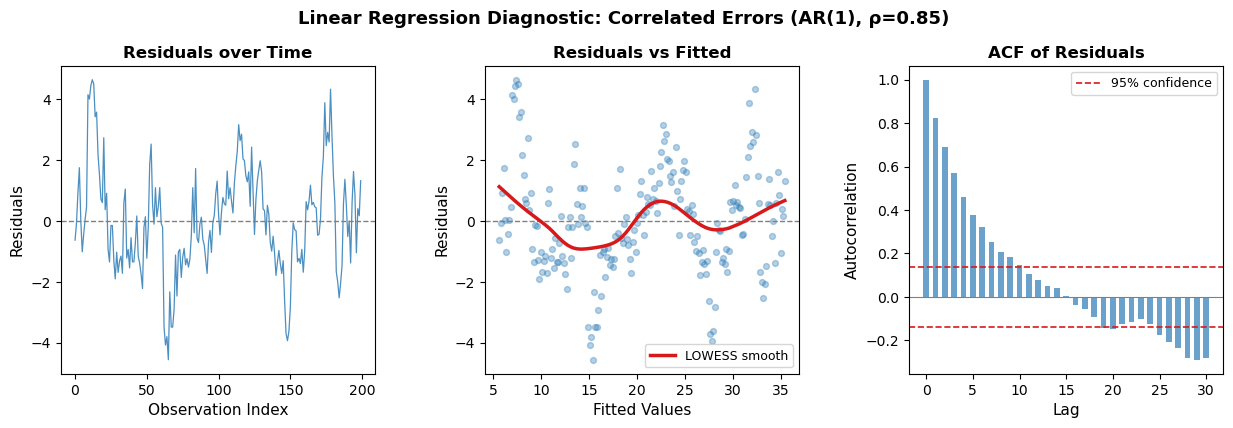

In [3]:
# --- Generate data with autocorrelated errors (AR(1)) ---
n = 200
X = np.linspace(0, 10, n)
 
# AR(1) errors: e_t = rho * e_{t-1} + noise
rho = 0.85
noise = np.random.normal(0, 1, n)
errors = np.zeros(n)
for t in range(1, n):
    errors[t] = rho * errors[t - 1] + noise[t]
 
y = 3 * X + 5 + errors
 
# Fit linear regression
model = LinearRegression().fit(X.reshape(-1, 1), y)
fitted = model.predict(X.reshape(-1, 1))
residuals = y - fitted
 
# LOWESS smooth on residuals vs fitted
smoothed = lowess(residuals, fitted, frac=0.4)
 
# Autocorrelation function (ACF) up to 30 lags
max_lag = 30
acf = [np.corrcoef(residuals[:-lag], residuals[lag:])[0, 1] for lag in range(1, max_lag + 1)]
acf = [1.0] + acf  # lag 0
confidence = 1.96 / np.sqrt(n)
 
# --- Plot ---
fig = plt.figure(figsize=(15, 4))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
 
# Left: Residuals over time
ax1 = fig.add_subplot(gs[0])
ax1.plot(np.arange(n), residuals, color="#2c7bb6", linewidth=0.9, alpha=0.85)
ax1.axhline(0, color="gray", linewidth=1, linestyle="--")
ax1.set_xlabel("Observation Index", fontsize=11)
ax1.set_ylabel("Residuals", fontsize=11)
ax1.set_title("Residuals over Time", fontsize=12, fontweight="bold")
 
# Middle: Residuals vs Fitted with LOWESS
ax2 = fig.add_subplot(gs[1])
ax2.axhline(0, color="gray", linewidth=1, linestyle="--")
ax2.scatter(fitted, residuals, alpha=0.35, s=18, color="#2c7bb6")
ax2.plot(smoothed[:, 0], smoothed[:, 1], color="#d7191c", linewidth=2.5, label="LOWESS smooth")
ax2.set_xlabel("Fitted Values", fontsize=11)
ax2.set_ylabel("Residuals", fontsize=11)
ax2.set_title("Residuals vs Fitted", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
 
# Right: ACF of residuals
ax3 = fig.add_subplot(gs[2])
lags = np.arange(0, max_lag + 1)
ax3.bar(lags, acf, color="#2c7bb6", alpha=0.7, width=0.6)
ax3.axhline(confidence, color="#d7191c", linewidth=1.2, linestyle="--", label="95% confidence")
ax3.axhline(-confidence, color="#d7191c", linewidth=1.2, linestyle="--")
ax3.axhline(0, color="gray", linewidth=0.8)
ax3.set_xlabel("Lag", fontsize=11)
ax3.set_ylabel("Autocorrelation", fontsize=11)
ax3.set_title("ACF of Residuals", fontsize=12, fontweight="bold")
ax3.legend(fontsize=9)
 
fig.suptitle("Linear Regression Diagnostic: Correlated Errors (AR(1), ρ=0.85)",
             fontsize=13, fontweight="bold", y=1.02)

This also took one iteration by Claude and three plots were generated. The left plot shows the residuals from the linear fitted data, the relationship here should not be correlated but instead shows a wave-like pattern. The middle plot plots the residuals vs fitted values like the last problem and shows a similar problem, the smooted curve is not flat and also reveals a wave like pattern. The third plot shows the autocorrelation very clearly and plots an autocorrelation function of the residuals, showing a strongly correlated example.

# Issue 3: Outliers

Outliers are points in the data whose y is far from the predicted value of the model. These points which can be errors in data collection can throw off linear regression coefficient estimates if not handled correctly. One way to handle outliers is to remove them from the raw data, before running the model.

**Q:** How can you be certain when classifying what an 'outlier' is?

**A:** Use statistical thresholds like Cook's distance to flag points and investigate further whether to decide if the outlier is legit and not just measurement error. Proceed carefully when removing outliers without justification and to just 'get a better fit'.

Text(0.5, 1.02, 'Linear Regression Diagnostic: Outliers & Influential Points')

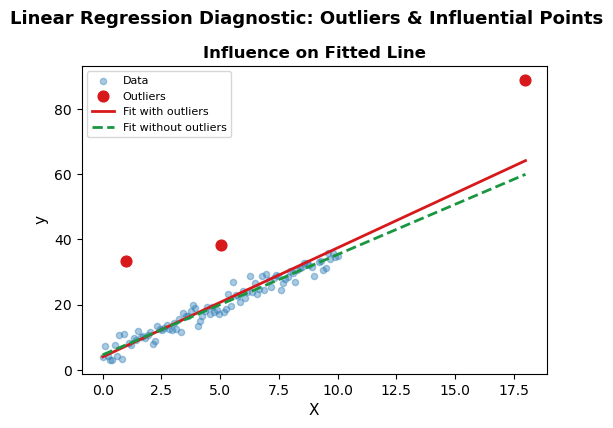

In [7]:
# --- Generate clean linear data with outliers injected ---
n = 100
X = np.linspace(0, 10, n)
y = 3 * X + 5 + np.random.normal(0, 2, n)
 
# Inject outliers: high leverage + influential points
outlier_idx = [10, 50, 90]
y[10] += 25    # vertical outlier, low leverage
y[50] += 20    # vertical outlier, mid leverage
X[90] = 18     # high leverage point, pulls fit
y[90] = 3 * X[90] + 5 + 30  # also high residual -> highly influential
 
# Fit with and without outliers
X_2d = X.reshape(-1, 1)
model = LinearRegression().fit(X_2d, y)
fitted = model.predict(X_2d)
residuals = y - fitted
 
mask = np.ones(n, dtype=bool)
mask[outlier_idx] = False
model_clean = LinearRegression().fit(X_2d[mask], y[mask])
 
# --- Plot ---
fig, ax1 = plt.subplots(figsize=(6, 4))
 
x_line = np.array([X.min(), X.max()])
ax1.scatter(X[mask], y[mask], alpha=0.4, s=20, color="#2c7bb6", label="Data")
ax1.scatter(X[outlier_idx], y[outlier_idx], s=60, color="#d7191c", zorder=5, label="Outliers")
ax1.plot(x_line, model.predict(x_line.reshape(-1, 1)), color="#d7191c", linewidth=2, label="Fit with outliers")
ax1.plot(x_line, model_clean.predict(x_line.reshape(-1, 1)), color="#1a9641", linewidth=2, linestyle="--", label="Fit without outliers")
ax1.set_xlabel("X", fontsize=11)
ax1.set_ylabel("y", fontsize=11)
ax1.set_title("Influence on Fitted Line", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8)
 
fig.suptitle("Linear Regression Diagnostic: Outliers & Influential Points",
             fontsize=13, fontweight="bold", y=1.02)

 
fig.suptitle("Linear Regression Diagnostic: Outliers & Influential Points",
             fontsize=13, fontweight="bold", y=1.02)

This result took 1.5 iterations. At first, Claude added two additional plots other than this one which included metrics like Cook's distance, an estimate of the influence of a data point, useful for evaluating outliers. I thought this wasn't neccessary and thought to only keep the first plot, showing how the linear fit gets thrown off when including the outliers, so I edited the code. When including the outliers, the regression coefficients are likely to be different, for example a steeper linear slope which can throw off conclusions from this model.